## 1. Install & Import Dependencies

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow openpyxl --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# ── Thesis-quality plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading & Exploratory Data Analysis

In [ ]:
df = pd.read_excel('/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
df['text']  = df.iloc[:, 0].astype(str)
df['label'] = df.iloc[:, 1].map({'Positive': 1, 'Negative': 0})
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Dataset shape : {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
print(f'\nSample texts:')
display(df[['text','label']].head(5))

Dataset shape : (82611, 5)
Label distribution:
label
0    41355
1    41256
Name: count, dtype: int64

Sample texts:


,text,label
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,1
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,1
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,1
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,1
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",1


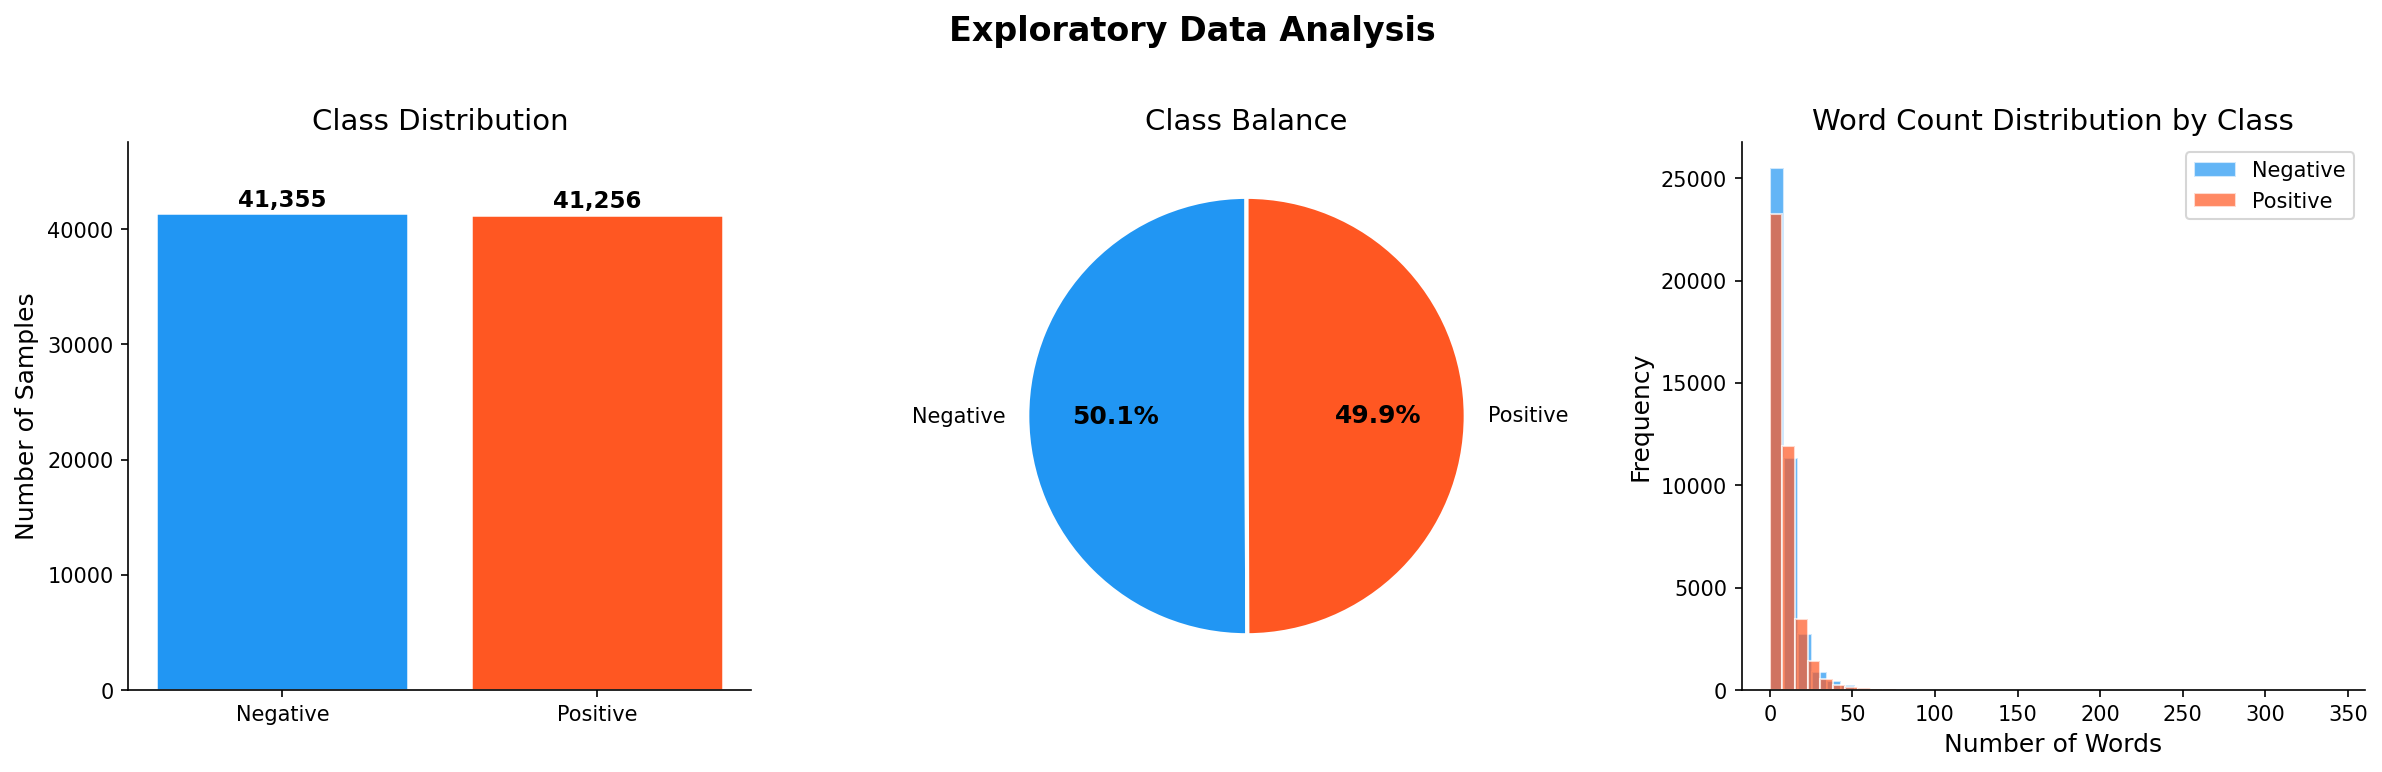

Figure 1 saved: fig01_eda.png


In [ ]:
# ── EDA: Class distribution & text-length stats ────────────────────────────
df['text_len'] = df['text'].str.len()
df['word_cnt'] = df['text'].str.split().str.len()

label_map   = {0: 'Negative', 1: 'Positive'}
label_names = [label_map[l] for l in df['label']]
counts      = df['label'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. Class distribution bar chart
ax = axes[0]
bars = ax.bar(['Negative', 'Positive'], [counts[0], counts[1]],
              color=PALETTE[:2], edgecolor='white', linewidth=1.2)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200,
            f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(counts) * 1.15)

# 2. Class distribution pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    [counts[0], counts[1]],
    labels=['Negative', 'Positive'],
    colors=PALETTE[:2],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Class Balance')

# 3. Word count distribution by class
ax = axes[2]
for lbl, color, name in zip([0, 1], PALETTE[:2], ['Negative', 'Positive']):
    ax.hist(df[df['label'] == lbl]['word_cnt'], bins=40, alpha=0.7,
            color=color, label=name, edgecolor='white')
ax.set_title('Word Count Distribution by Class')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('fig01_eda.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved: fig01_eda.png')

## 3. Train / Test Split & Feature Engineering

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

# TF-IDF features (for Random Forest)
tfidf          = TfidfVectorizer(max_features=5000)
X_train_tfidf  = tfidf.fit_transform(X_train)
X_test_tfidf   = tfidf.transform(X_test)

# Sequence features (for CNN & TNN)
MAX_WORDS, MAX_LEN = 5000, 100
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)
print('Feature engineering complete.')

Train size: 66,088  |  Test size: 16,523
Feature engineering complete.


## 4. Base Model Training

### 4a. Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_pred_train = rf.predict_proba(X_train_tfidf)
rf_pred_test  = rf.predict_proba(X_test_tfidf)
rf_y_pred     = rf.predict(X_test_tfidf)
rf_acc        = accuracy_score(y_test, rf_y_pred)
print(f'Random Forest Test Accuracy: {rf_acc:.4f}')

Random Forest Test Accuracy: 0.7618


### 4b. CNN (Text CNN)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

cnn = Sequential([
    Embedding(MAX_WORDS, 128),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_history = cnn.fit(
    X_train_seq, y_train,
    epochs=10, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
cnn_pred_train = cnn.predict(X_train_seq, verbose=0)
cnn_pred_test  = cnn.predict(X_test_seq,  verbose=0)
cnn_y_pred     = (cnn_pred_test >= 0.5).astype(int).flatten()
cnn_acc        = accuracy_score(y_test, cnn_y_pred)
print(f'CNN Test Accuracy: {cnn_acc:.4f}')

Epoch 1/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7468 - loss: 0.5086 - val_accuracy: 0.7821 - val_loss: 0.4592
Epoch 2/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8272 - loss: 0.3858 - val_accuracy: 0.7953 - val_loss: 0.4599
Epoch 3/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8833 - loss: 0.2811 - val_accuracy: 0.7945 - val_loss: 0.4761
CNN Test Accuracy: 0.7796


### 4c. TNN (Token Neural Network — Embedding + Global Pooling)

In [ ]:
tnn = Sequential([
    Embedding(MAX_WORDS, 128),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
tnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
tnn_history = tnn.fit(
    X_train_seq, y_train,
    epochs=10, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
tnn_pred_train = tnn.predict(X_train_seq, verbose=0)
tnn_pred_test  = tnn.predict(X_test_seq,  verbose=0)
tnn_y_pred     = (tnn_pred_test >= 0.5).astype(int).flatten()
tnn_acc        = accuracy_score(y_test, tnn_y_pred)
print(f'TNN Test Accuracy: {tnn_acc:.4f}')

Epoch 1/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7401 - loss: 0.5167 - val_accuracy: 0.7794 - val_loss: 0.4647
Epoch 2/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8198 - loss: 0.3997 - val_accuracy: 0.7932 - val_loss: 0.4453
Epoch 3/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8552 - loss: 0.3339 - val_accuracy: 0.8033 - val_loss: 0.4459
Epoch 4/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8852 - loss: 0.2734 - val_accuracy: 0.8063 - val_loss: 0.4662
TNN Test Accuracy: 0.7884


## 5. Meta-Learner (Logistic Regression Stacking)

In [ ]:
X_train_stack = np.column_stack((
    rf_pred_train[:, 1],
    cnn_pred_train.flatten(),
    tnn_pred_train.flatten()
))
X_test_stack = np.column_stack((
    rf_pred_test[:, 1],
    cnn_pred_test.flatten(),
    tnn_pred_test.flatten()
))

meta = LogisticRegression(max_iter=1000, random_state=42)
meta.fit(X_train_stack, y_train)
pred       = meta.predict(X_test_stack)
pred_proba = meta.predict_proba(X_test_stack)[:, 1]

ensemble_acc = accuracy_score(y_test, pred)
print(f'Ensemble (Stacking) Test Accuracy: {ensemble_acc:.4f}')
print()
print(classification_report(y_test, pred, target_names=['Negative', 'Positive']))

Ensemble (Stacking) Test Accuracy: 0.8071

              precision    recall  f1-score   support

    Negative       0.80      0.81      0.81      8271
    Positive       0.81      0.80      0.81      8252

    accuracy                           0.81     16523
   macro avg       0.81      0.81      0.81     16523
weighted avg       0.81      0.81      0.81     16523



## 6. Comprehensive Thesis Visualizations

### Figure 2 — Confusion Matrices (All Models)

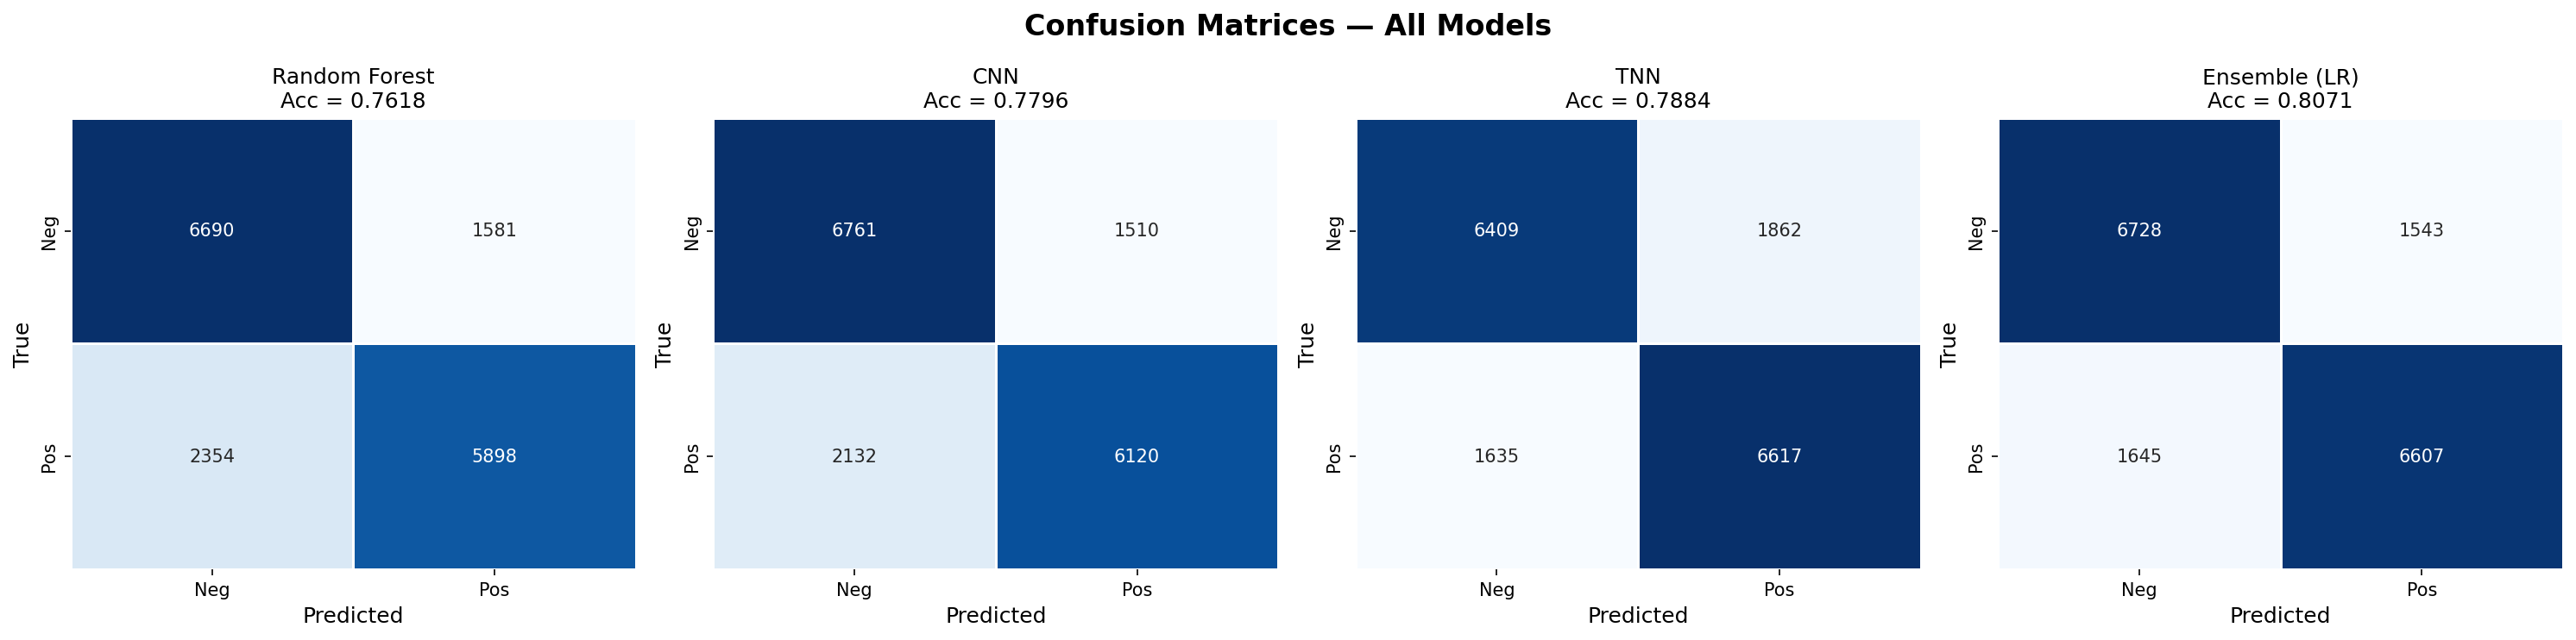

Figure 2 saved: fig02_confusion_matrices.png


In [ ]:
models_info = [
    ('Random Forest',  rf_y_pred),
    ('CNN',            cnn_y_pred),
    ('TNN',            tnn_y_pred),
    ('Ensemble (LR)',  pred),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

for ax, (name, yp) in zip(axes, models_info):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Neg', 'Pos'],
        yticklabels=['Neg', 'Pos'],
        ax=ax, cbar=False, linewidths=0.5
    )
    acc = accuracy_score(y_test, yp)
    ax.set_title(f'{name}\nAcc = {acc:.4f}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('fig02_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved: fig02_confusion_matrices.png')

### Figure 3 — ROC Curves (All Models)

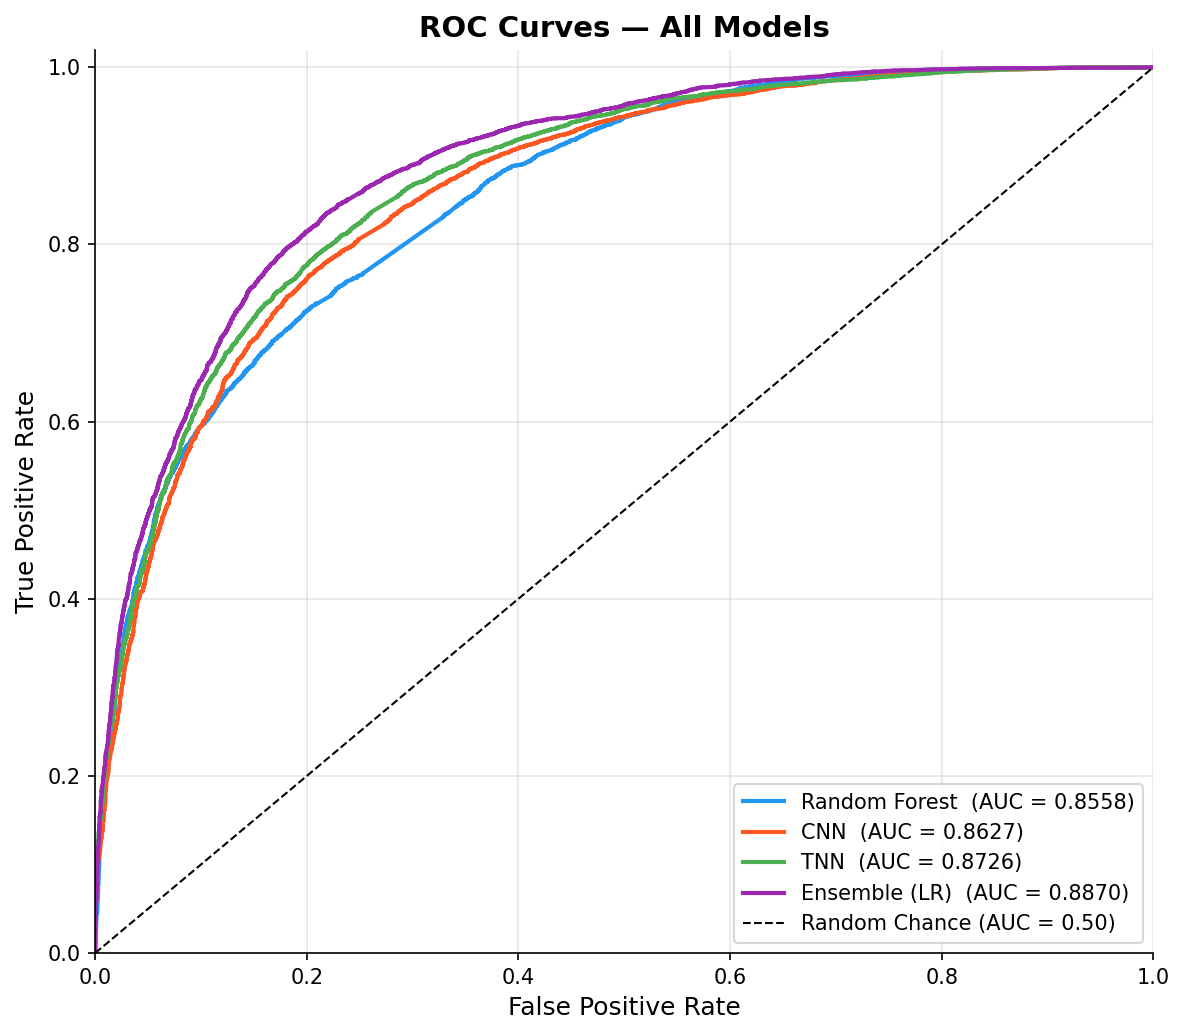

Figure 3 saved: fig03_roc_curves.png


In [ ]:
# Collect predicted probabilities
proba_dict = {
    'Random Forest': rf_pred_test[:, 1],
    'CNN':           cnn_pred_test.flatten(),
    'TNN':           tnn_pred_test.flatten(),
    'Ensemble (LR)': pred_proba,
}

fig, ax = plt.subplots(figsize=(8, 7))

for (name, proba), color in zip(proba_dict.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.50)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig03_roc_curves.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved: fig03_roc_curves.png')

### Figure 4 — Precision-Recall Curves (All Models)

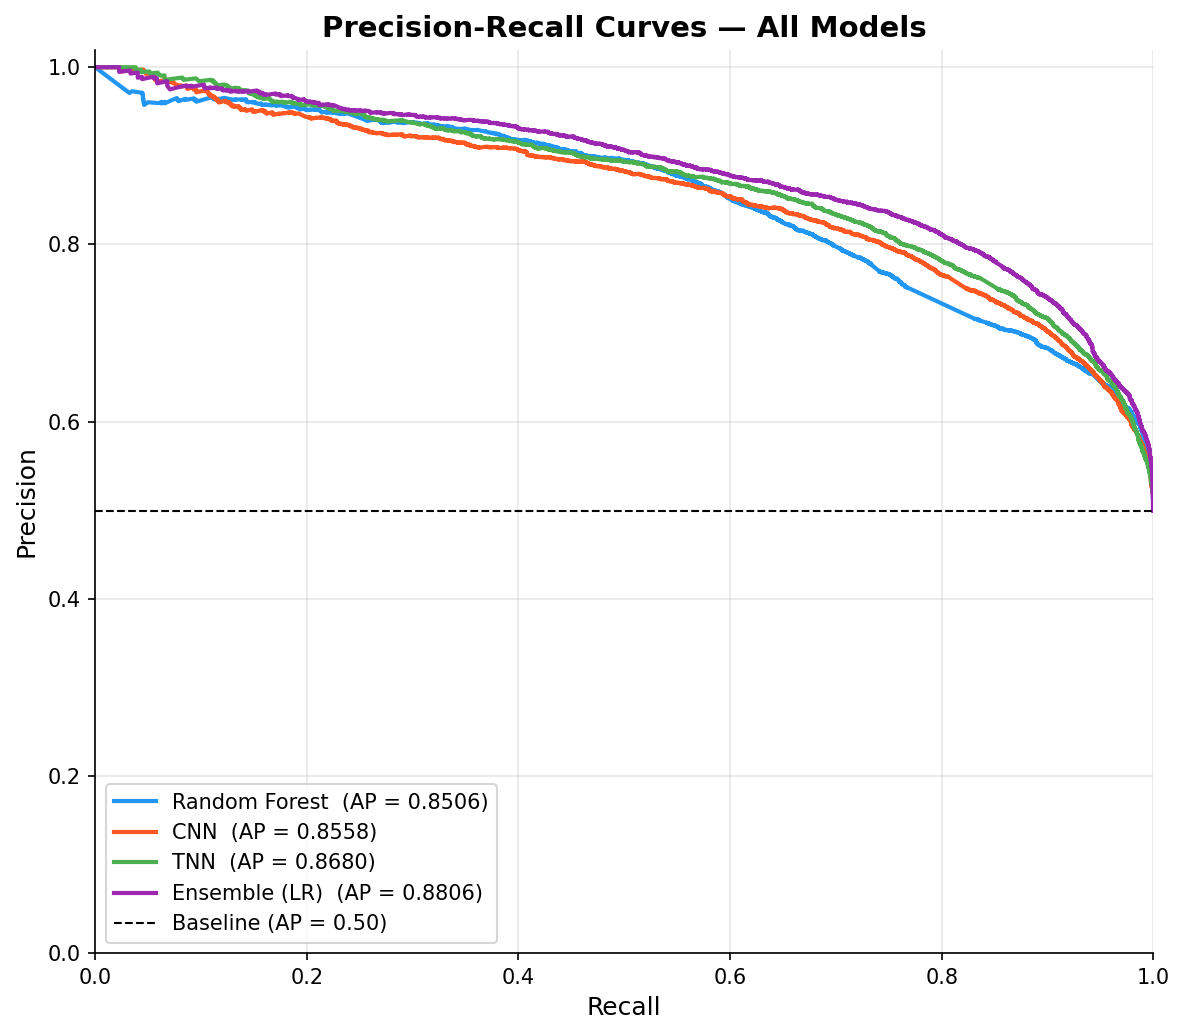

Figure 4 saved: fig04_pr_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

for (name, proba), color in zip(proba_dict.items(), PALETTE):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=color, lw=2, label=f'{name}  (AP = {ap:.4f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline (AP = {baseline:.2f})')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig04_pr_curves.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved: fig04_pr_curves.png')

### Figure 5 — Model Performance Comparison Bar Chart


Performance Summary:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.7618,0.7886,0.7147,0.7499,0.8558
CNN,0.7796,0.8021,0.7416,0.7707,0.8627
TNN,0.7884,0.7804,0.8019,0.7910,0.8726
Ensemble (LR),0.8071,0.8107,0.8007,0.8056,0.8870


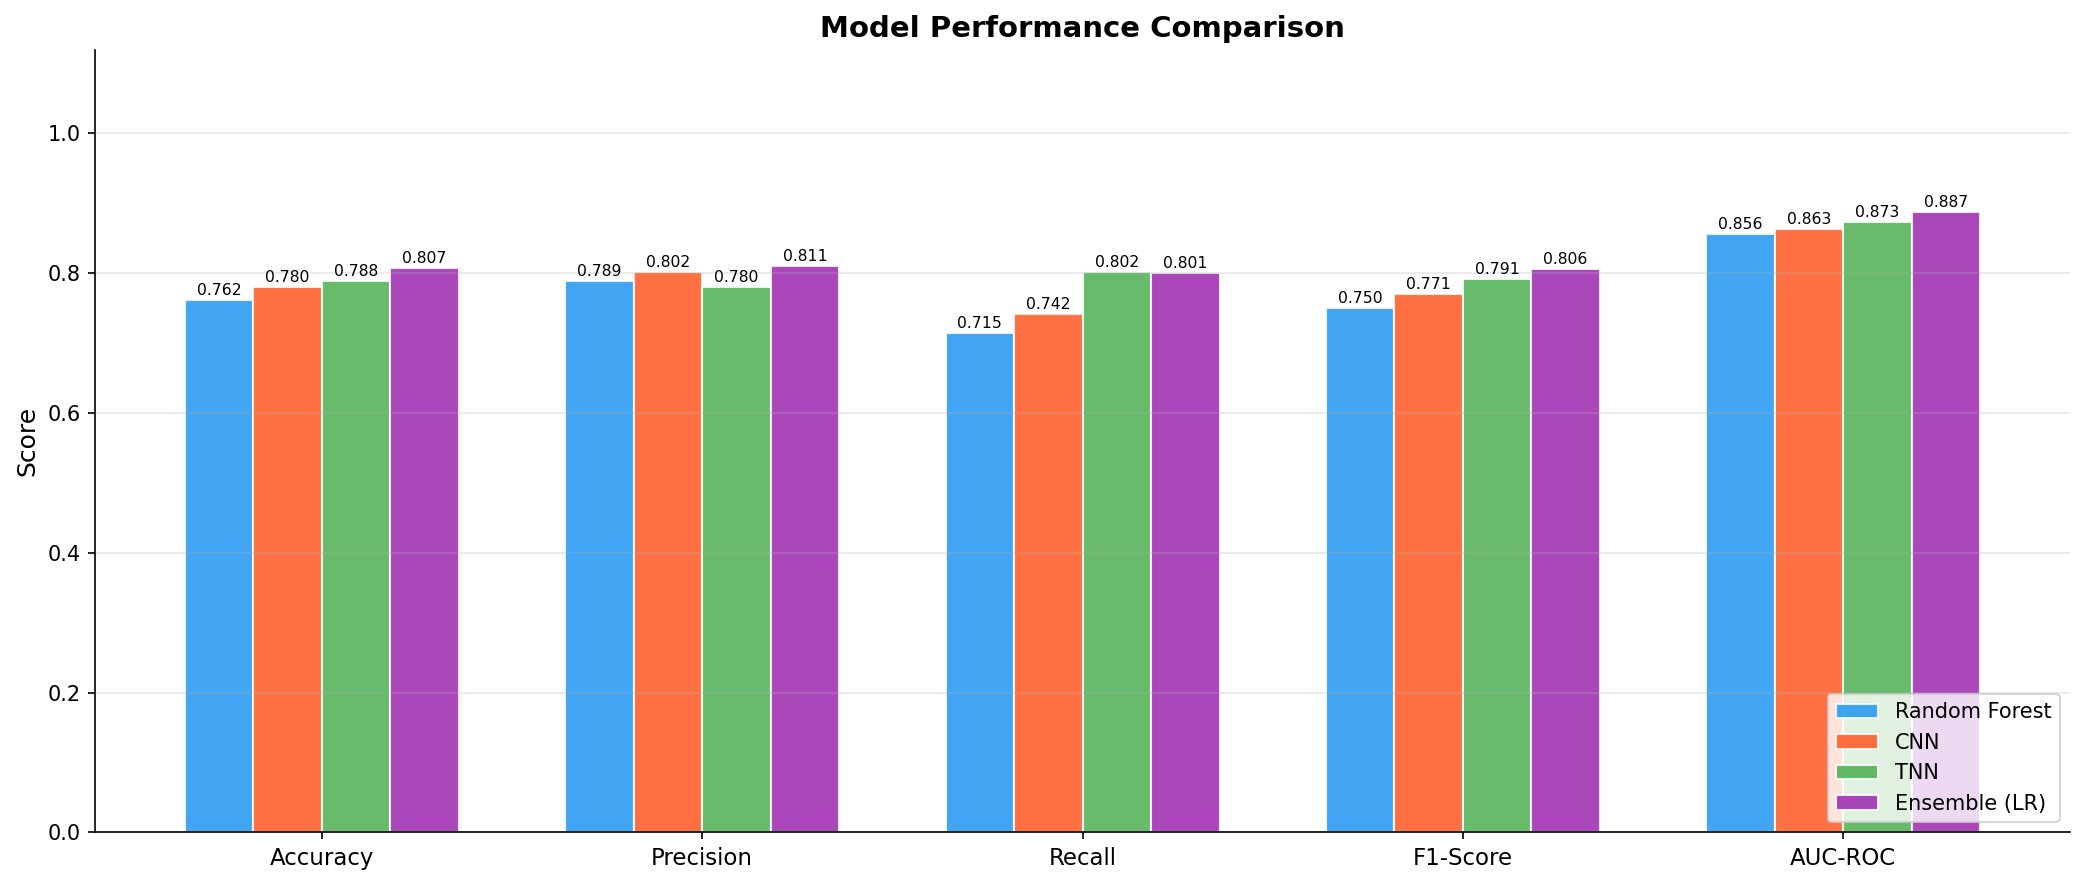

Figure 5 saved: fig05_performance_bar.png


In [ ]:
def get_metrics(y_true, y_pred, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
        'AUC-ROC':   auc(fpr, tpr),
    }

metrics_all = {
    'Random Forest':  get_metrics(y_test, rf_y_pred,  rf_pred_test[:, 1]),
    'CNN':            get_metrics(y_test, cnn_y_pred, cnn_pred_test.flatten()),
    'TNN':            get_metrics(y_test, tnn_y_pred, tnn_pred_test.flatten()),
    'Ensemble (LR)':  get_metrics(y_test, pred,       pred_proba),
}

metrics_df = pd.DataFrame(metrics_all).T
print('\nPerformance Summary:')
display(metrics_df.round(4))

# Grouped bar chart
metric_names = list(metrics_df.columns)
model_names  = list(metrics_df.index)
x            = np.arange(len(metric_names))
width        = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, color) in enumerate(zip(model_names, PALETTE)):
    vals = metrics_df.loc[model].values
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig05_performance_bar.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved: fig05_performance_bar.png')

### Figure 6 — CNN & TNN Training / Validation Curves

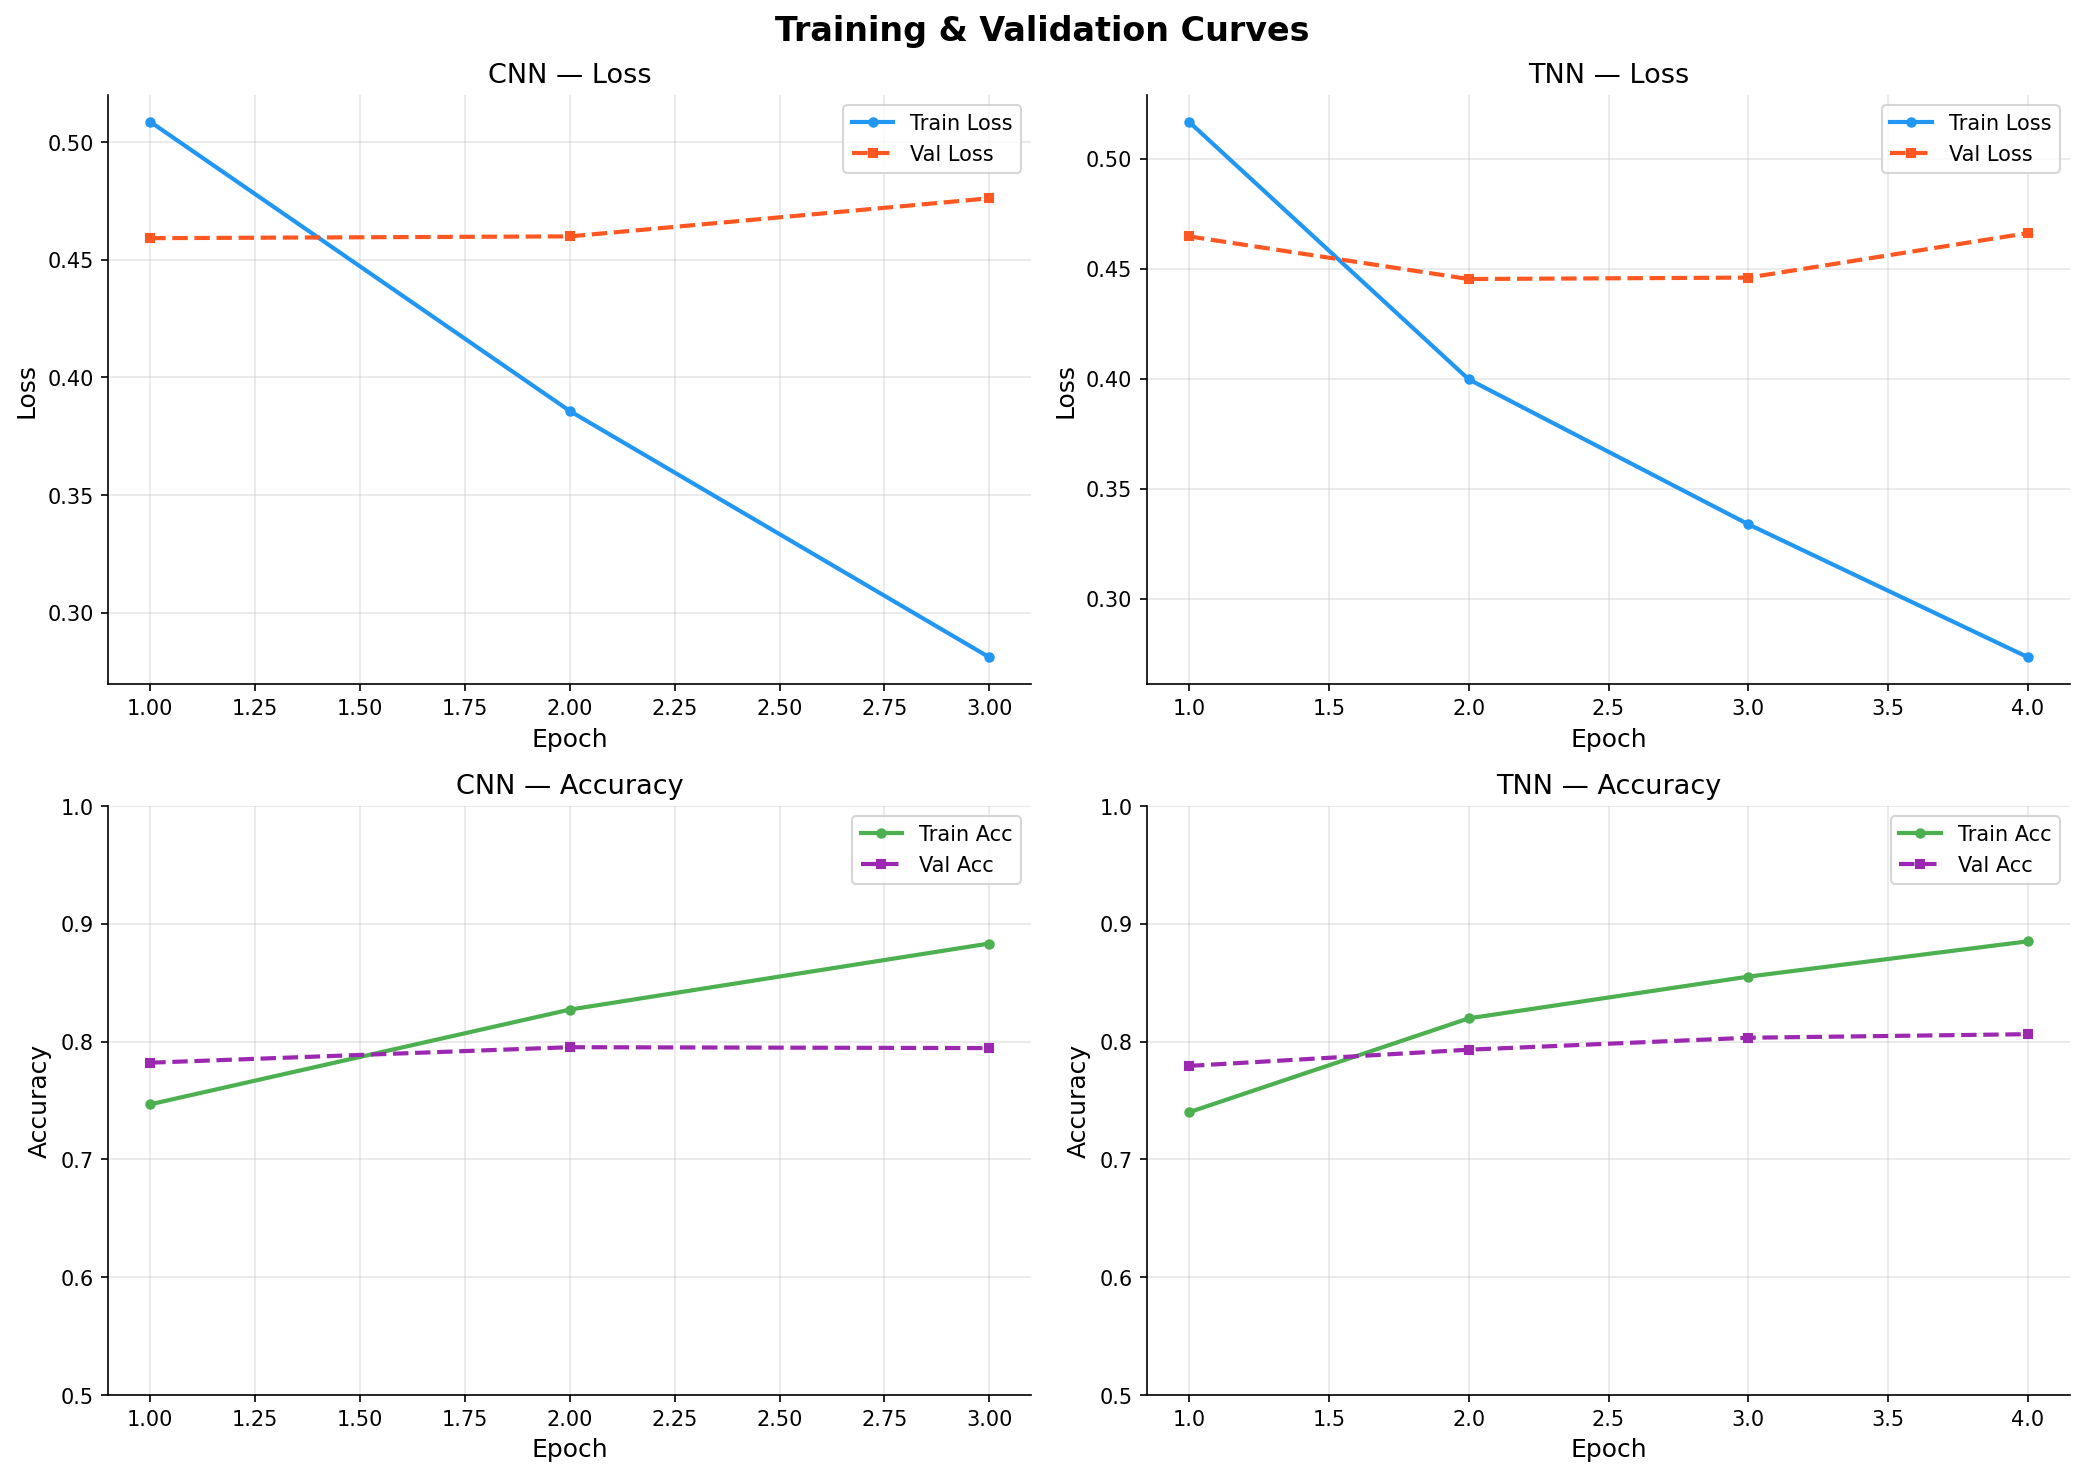

Figure 6 saved: fig06_training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training & Validation Curves', fontsize=16, fontweight='bold')

histories = [('CNN', cnn_history), ('TNN', tnn_history)]

for col, (name, hist) in enumerate(histories):
    epochs = range(1, len(hist.history['loss']) + 1)

    # Loss
    ax = axes[0][col]
    ax.plot(epochs, hist.history['loss'],     color=PALETTE[0], lw=2, marker='o', ms=4, label='Train Loss')
    ax.plot(epochs, hist.history['val_loss'], color=PALETTE[1], lw=2, marker='s', ms=4, label='Val Loss', linestyle='--')
    ax.set_title(f'{name} — Loss', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1][col]
    ax.plot(epochs, hist.history['accuracy'],     color=PALETTE[2], lw=2, marker='o', ms=4, label='Train Acc')
    ax.plot(epochs, hist.history['val_accuracy'], color=PALETTE[3], lw=2, marker='s', ms=4, label='Val Acc', linestyle='--')
    ax.set_title(f'{name} — Accuracy', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig06_training_curves.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved: fig06_training_curves.png')

### Figure 7 — Prediction Probability Distribution (Ensemble)

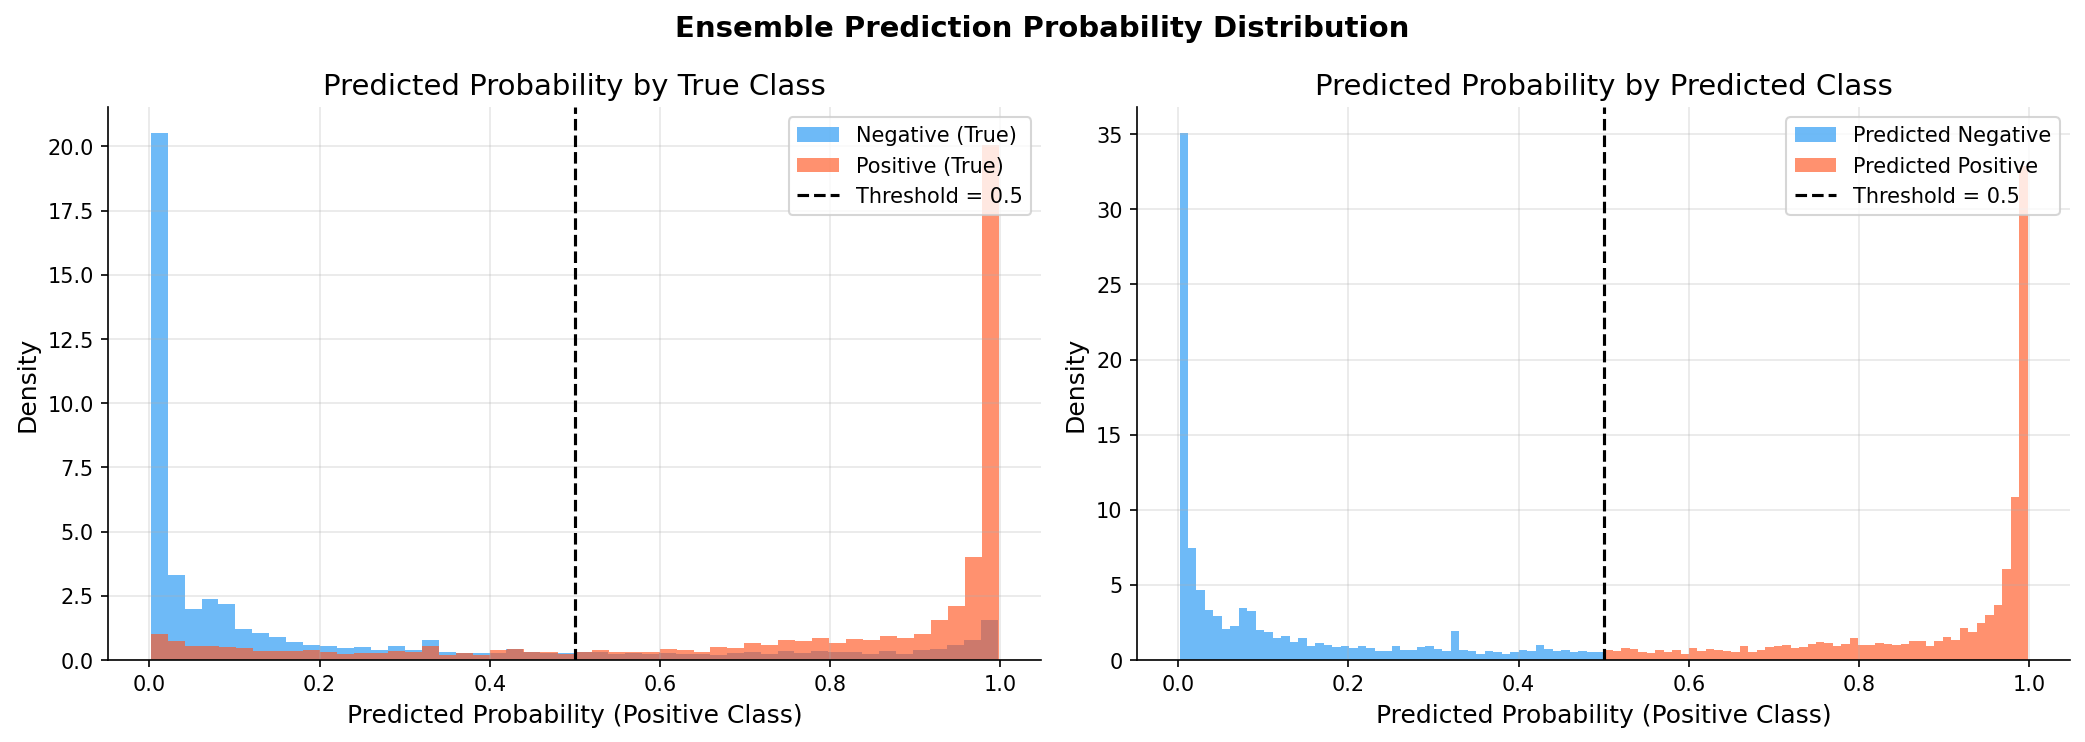

Figure 7 saved: fig07_prob_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ensemble Prediction Probability Distribution', fontsize=14, fontweight='bold')

# By true class
ax = axes[0]
for lbl, color, name in zip([0, 1], PALETTE[:2], ['Negative (True)', 'Positive (True)']):
    mask = (y_test == lbl)
    ax.hist(pred_proba[mask], bins=50, alpha=0.65, color=color, label=name, density=True)
ax.axvline(0.5, color='k', linestyle='--', lw=1.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability (Positive Class)')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability by True Class')
ax.legend()
ax.grid(alpha=0.3)

# By predicted class
ax = axes[1]
for lbl, color, name in zip([0, 1], PALETTE[:2], ['Predicted Negative', 'Predicted Positive']):
    mask = (pred == lbl)
    ax.hist(pred_proba[mask], bins=50, alpha=0.65, color=color, label=name, density=True)
ax.axvline(0.5, color='k', linestyle='--', lw=1.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability (Positive Class)')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability by Predicted Class')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig07_prob_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved: fig07_prob_distribution.png')

### Figure 8 — Calibration Curve (Reliability Diagram)

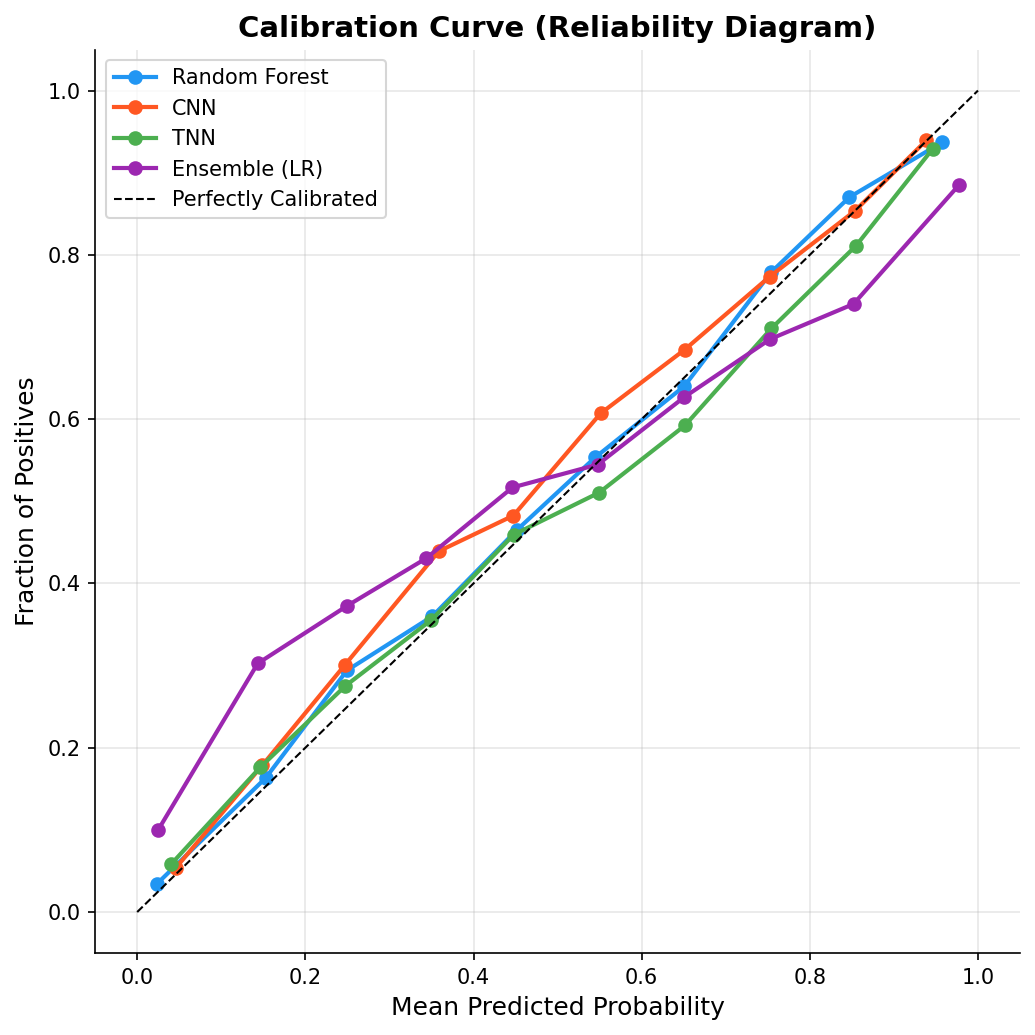

Figure 8 saved: fig08_calibration.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

for (name, proba), color in zip(proba_dict.items(), PALETTE):
    fraction_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, fraction_pos, marker='o', lw=2, color=color, label=name)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Reliability Diagram)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig08_calibration.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved: fig08_calibration.png')

### Figure 9 — Random Forest Feature Importances (Top 20 TF-IDF Terms)

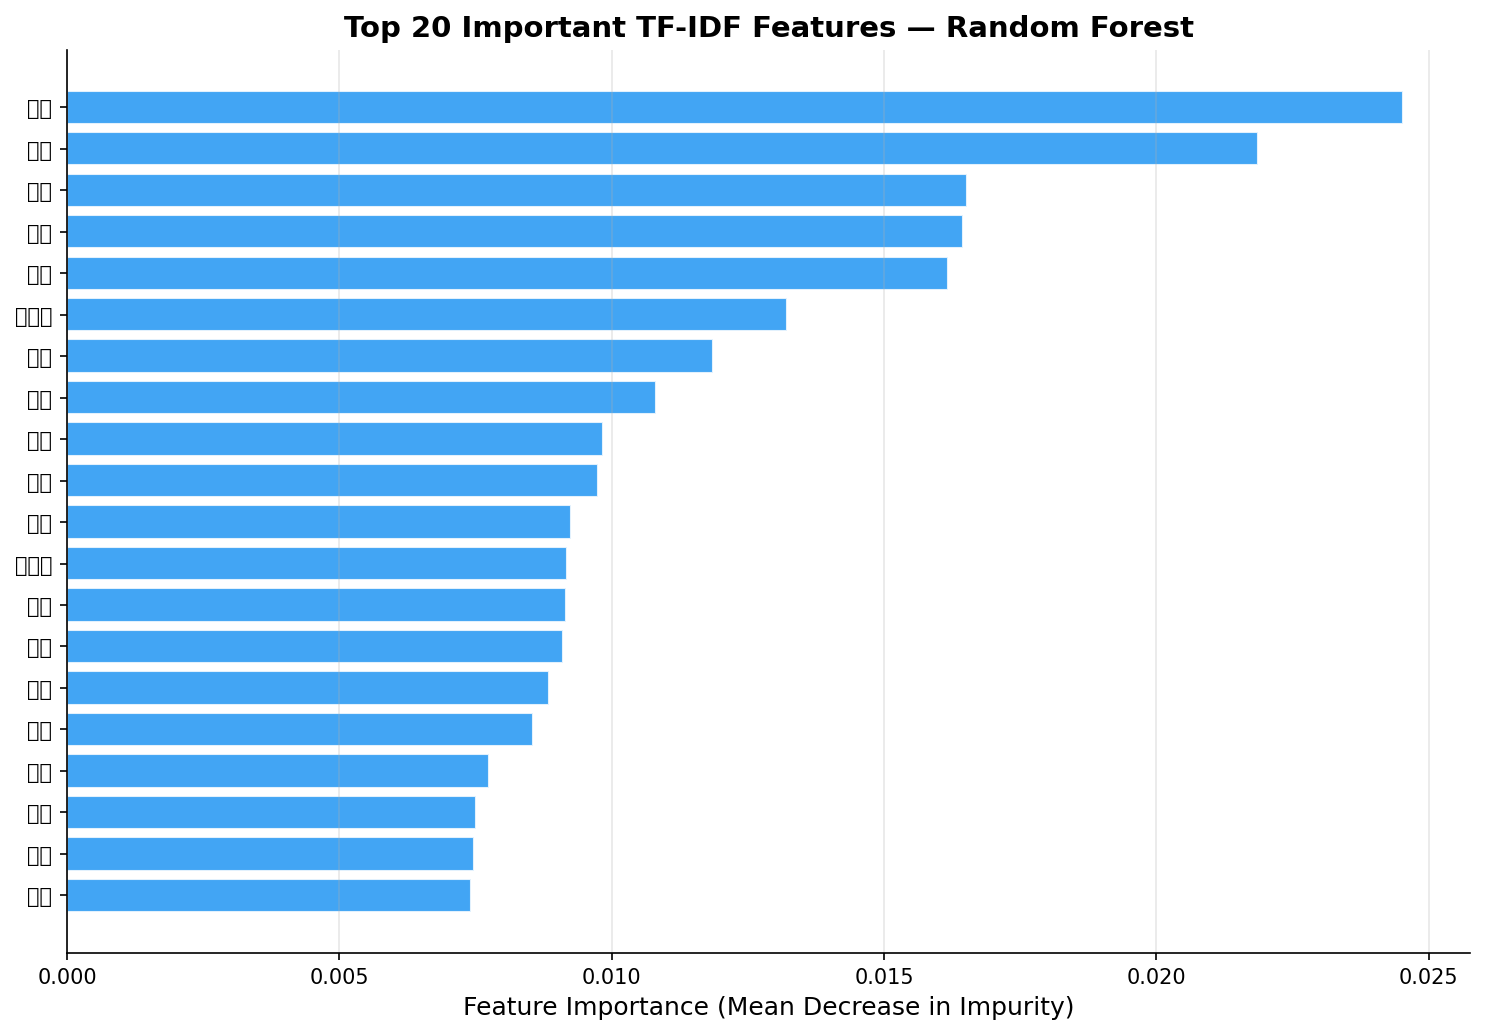

Figure 9 saved: fig09_feature_importance.png


In [ ]:
feature_names       = np.array(tfidf.get_feature_names_out())
importances         = rf.feature_importances_
top_idx             = np.argsort(importances)[::-1][:20]
top_features        = feature_names[top_idx]
top_importances     = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(20), top_importances[::-1], color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.set_yticks(range(20))
ax.set_yticklabels(top_features[::-1], fontsize=10)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 20 Important TF-IDF Features — Random Forest', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig09_feature_importance.png', bbox_inches='tight')
plt.show()
print('Figure 9 saved: fig09_feature_importance.png')

### Figure 10 — Heatmap of Per-Class Metrics Across Models

               Neg Precision  Neg Recall  Neg F1  Pos Precision  Pos Recall  \
Model                                                                         
Random Forest         0.7397      0.8089  0.7727         0.7886      0.7147   
CNN                   0.7603      0.8174  0.7878         0.8021      0.7416   
TNN                   0.7967      0.7749  0.7857         0.7804      0.8019   
Ensemble (LR)         0.8035      0.8134  0.8085         0.8107      0.8007   

               Pos F1  Macro F1  Weighted F1  
Model                                         
Random Forest  0.7499    0.7613       0.7613  
CNN            0.7707    0.7792       0.7793  
TNN            0.7910    0.7883       0.7883  
Ensemble (LR)  0.8056    0.8070       0.8070  


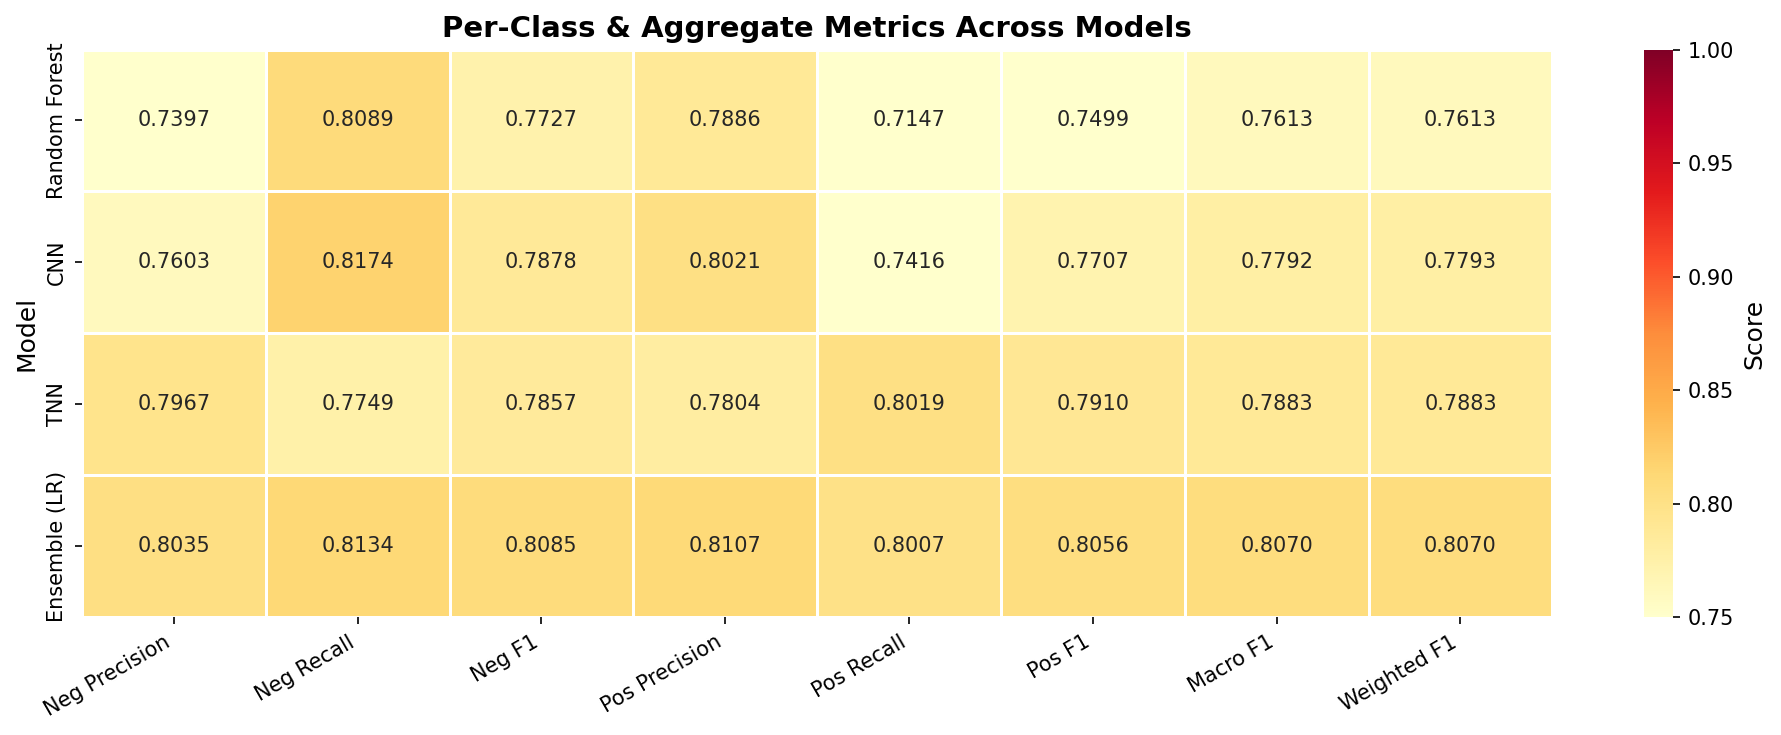

Figure 10 saved: fig10_metrics_heatmap.png


In [ ]:
rows = []
for model_name, yp in models_info:
    report = classification_report(y_test, yp, output_dict=True)
    rows.append({
        'Model':              model_name,
        'Neg Precision':      report['0']['precision'],
        'Neg Recall':         report['0']['recall'],
        'Neg F1':             report['0']['f1-score'],
        'Pos Precision':      report['1']['precision'],
        'Pos Recall':         report['1']['recall'],
        'Pos F1':             report['1']['f1-score'],
        'Macro F1':           report['macro avg']['f1-score'],
        'Weighted F1':        report['weighted avg']['f1-score'],
    })

heat_df = pd.DataFrame(rows).set_index('Model')
print(heat_df.round(4))

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heat_df.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, vmin=0.75, vmax=1.0, cbar_kws={'label': 'Score'}
)
ax.set_title('Per-Class & Aggregate Metrics Across Models', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig10_metrics_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 10 saved: fig10_metrics_heatmap.png')

### Figure 11 — Stacking Meta-Learner: Base Model Probability Scatter

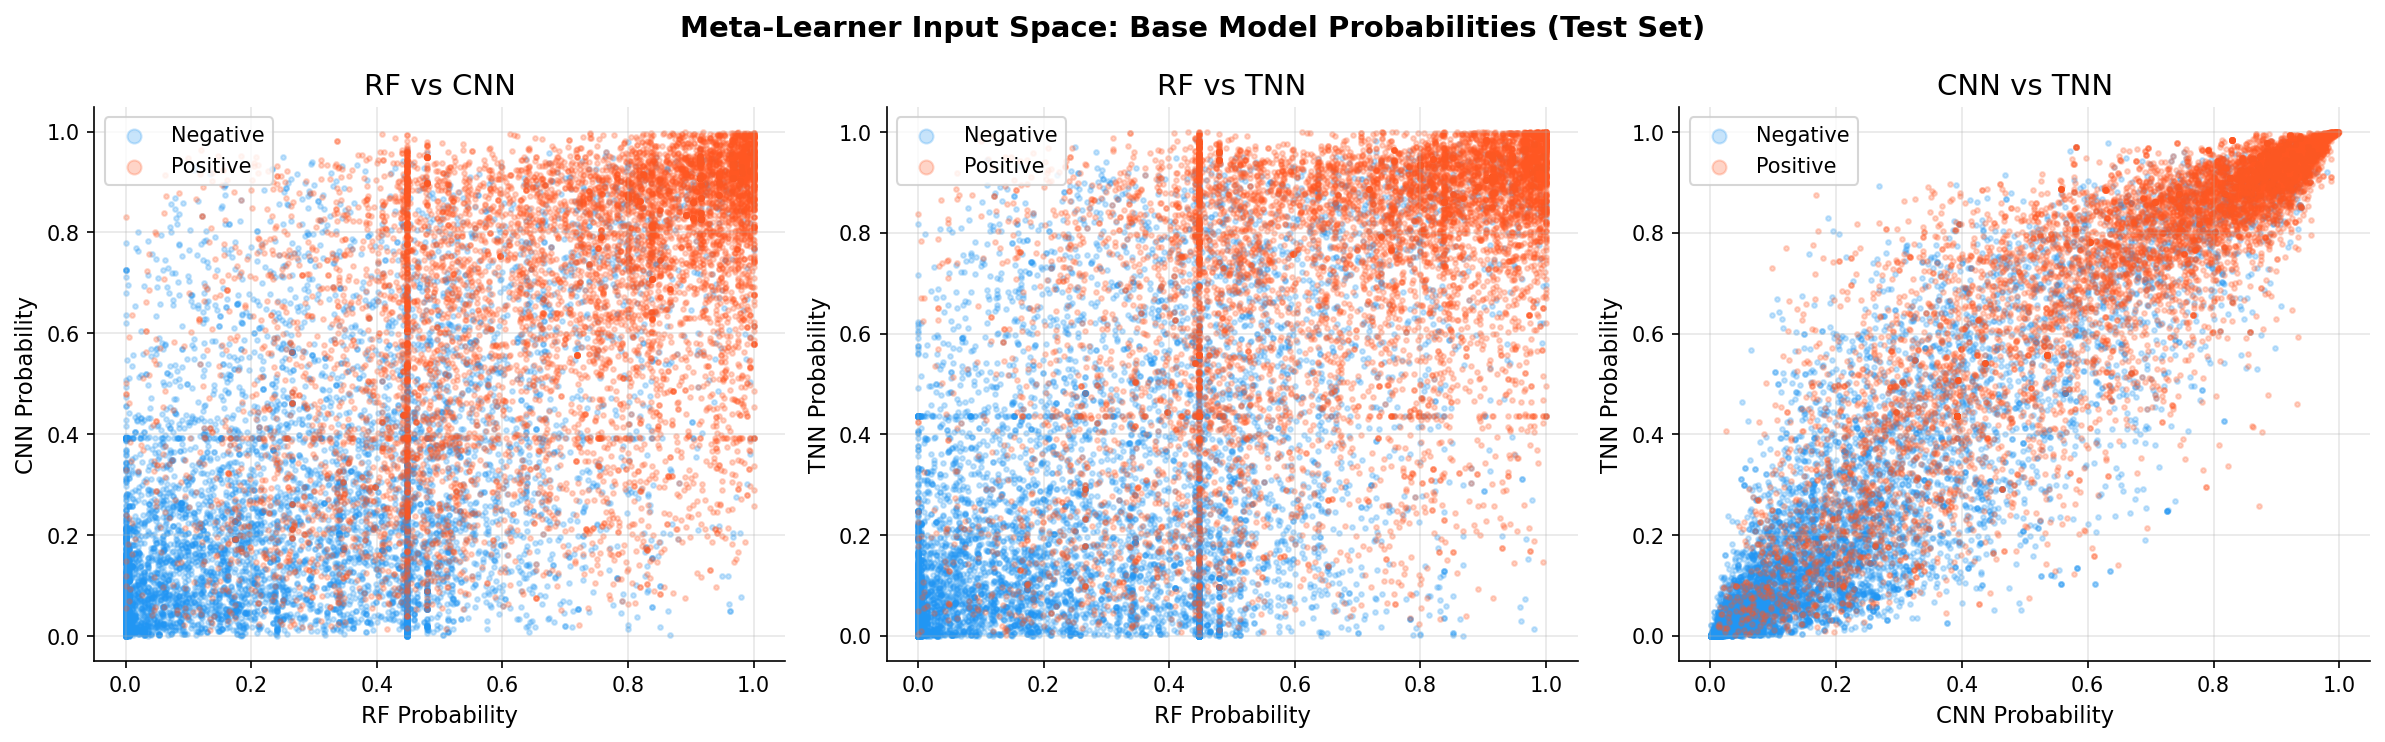

Figure 11 saved: fig11_meta_scatter.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Meta-Learner Input Space: Base Model Probabilities (Test Set)',
             fontsize=14, fontweight='bold')

pairs   = [('RF', 0, 'CNN', 1), ('RF', 0, 'TNN', 2), ('CNN', 1, 'TNN', 2)]
labels_ = ['Negative', 'Positive']

for ax, (xname, xi, yname, yi) in zip(axes, pairs):
    for lbl, color, lname in zip([0, 1], PALETTE[:2], labels_):
        mask = (y_test == lbl)
        ax.scatter(
            X_test_stack[mask, xi],
            X_test_stack[mask, yi],
            c=color, alpha=0.25, s=5, label=lname
        )
    ax.set_xlabel(f'{xname} Probability', fontsize=11)
    ax.set_ylabel(f'{yname} Probability', fontsize=11)
    ax.set_title(f'{xname} vs {yname}')
    ax.legend(markerscale=3)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig11_meta_scatter.png', bbox_inches='tight')
plt.show()
print('Figure 11 saved: fig11_meta_scatter.png')

### Figure 12 — Learning Curve (Ensemble / Meta-Learner)

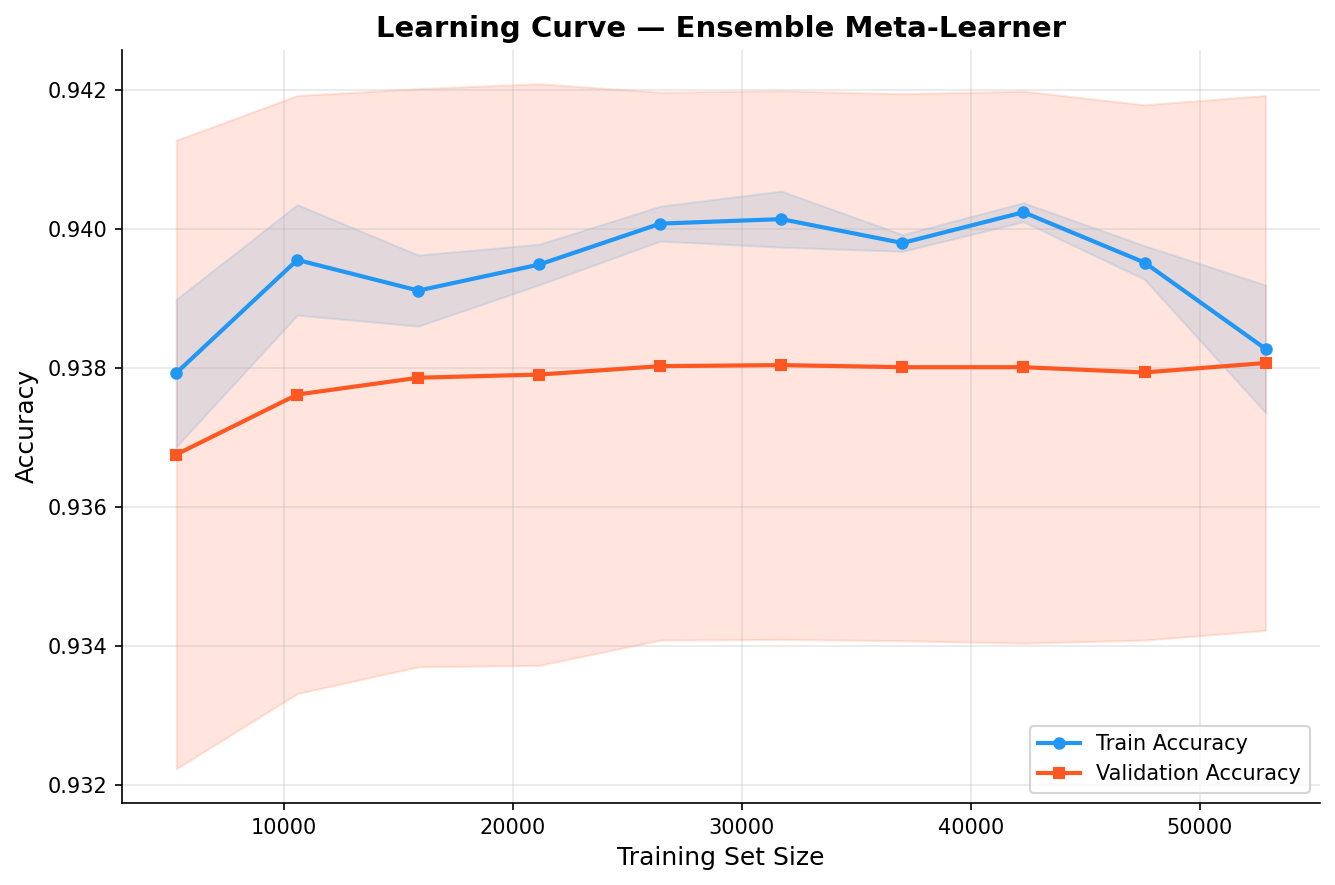

Figure 12 saved: fig12_learning_curve.png


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000),
    X_train_stack, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_mean, color=PALETTE[0], lw=2, marker='o', ms=5, label='Train Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color=PALETTE[0], alpha=0.15)
ax.plot(train_sizes, val_mean, color=PALETTE[1], lw=2, marker='s', ms=5, label='Validation Accuracy')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color=PALETTE[1], alpha=0.15)
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — Ensemble Meta-Learner', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig12_learning_curve.png', bbox_inches='tight')
plt.show()
print('Figure 12 saved: fig12_learning_curve.png')

### Figure 13 — Summary Dashboard (All Key Results)

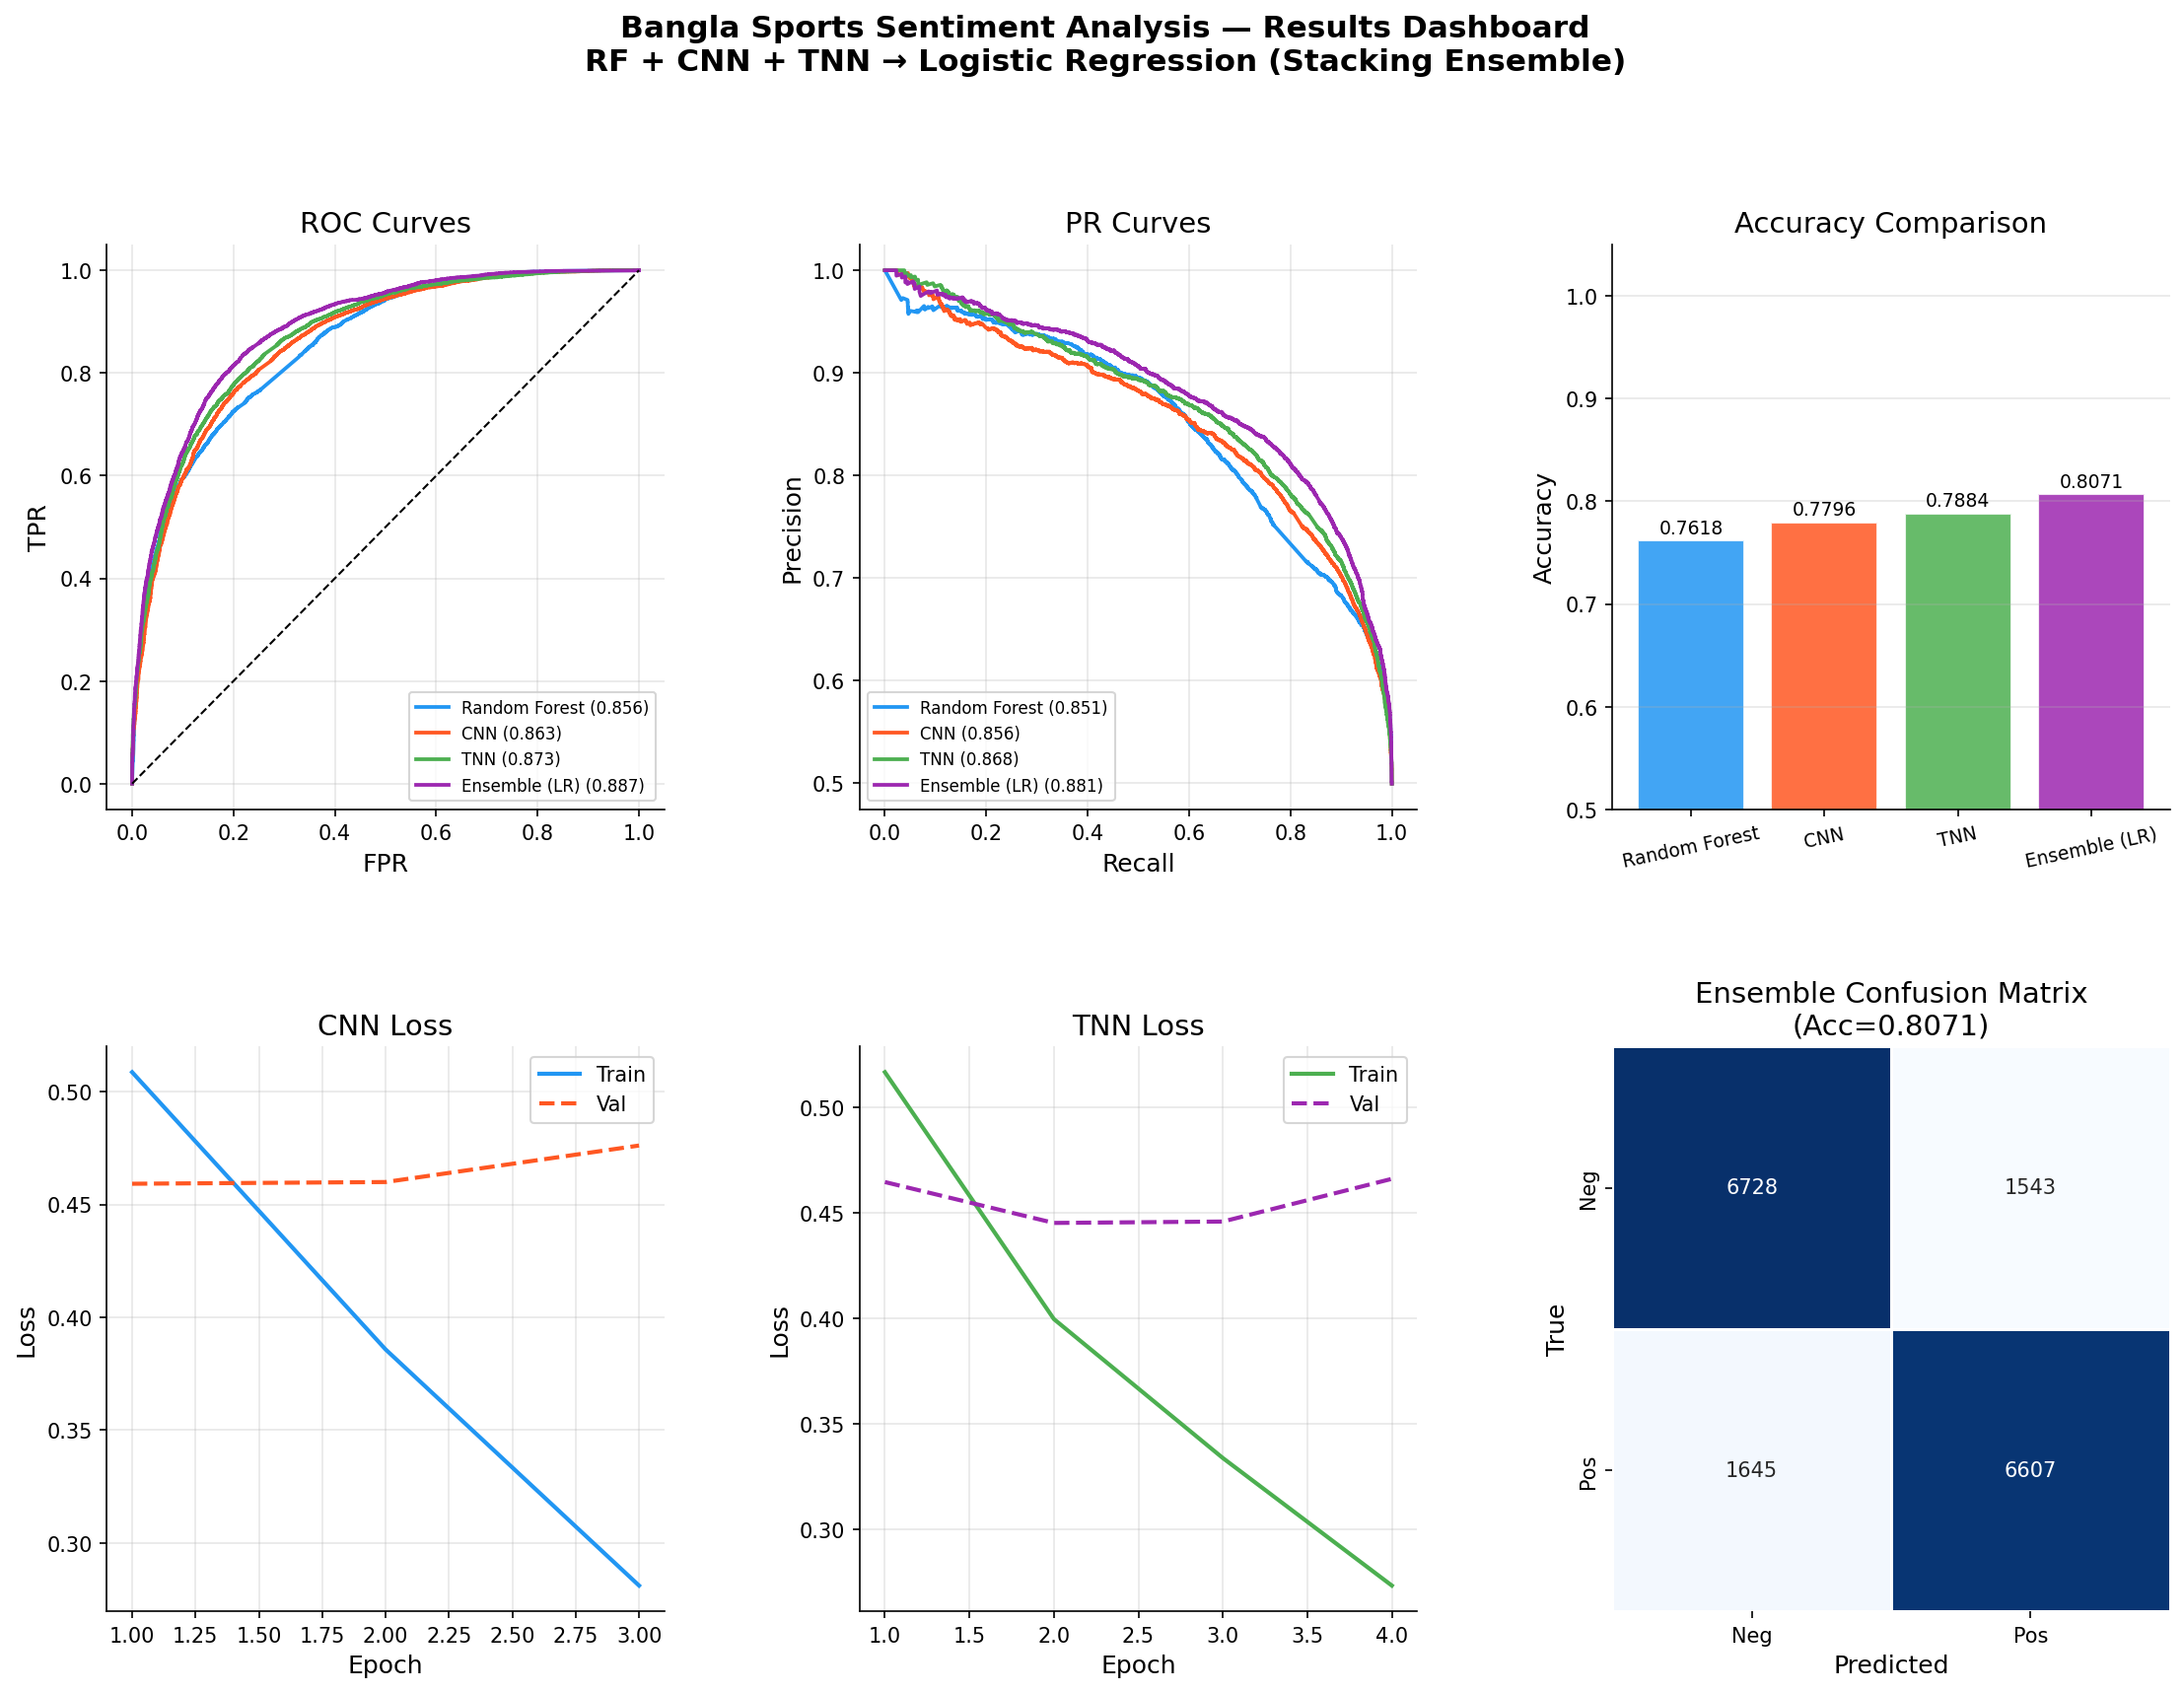

Figure 13 saved: fig13_summary_dashboard.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Bangla Sports Sentiment Analysis — Results Dashboard\n'
    'RF + CNN + TNN → Logistic Regression (Stacking Ensemble)',
    fontsize=15, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── ROC ────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for (name, proba), color in zip(proba_dict.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, color=color, lw=1.8, label=f'{name} ({auc(fpr,tpr):.3f})')
ax1.plot([0,1],[0,1],'k--',lw=1)
ax1.set_title('ROC Curves'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── PR ─────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for (name, proba), color in zip(proba_dict.items(), PALETTE):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax2.plot(rec, prec, color=color, lw=1.8, label=f'{name} ({ap:.3f})')
ax2.set_title('PR Curves'); ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(fontsize=8, loc='lower left'); ax2.grid(alpha=0.3)

# ── Accuracy bar ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
model_names_ = [n for n,_ in models_info]
accs = [accuracy_score(y_test, yp) for _,yp in models_info]
bars = ax3.bar(model_names_, accs, color=PALETTE[:4], alpha=0.85, edgecolor='white')
for b in bars:
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
             f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax3.set_ylim(0.5, 1.05)
ax3.set_ylabel('Accuracy'); ax3.set_title('Accuracy Comparison')
ax3.set_xticklabels(model_names_, rotation=12, fontsize=9); ax3.grid(axis='y', alpha=0.3)

# ── CNN training loss ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
e = range(1, len(cnn_history.history['loss'])+1)
ax4.plot(e, cnn_history.history['loss'],     color=PALETTE[0], lw=2, label='Train')
ax4.plot(e, cnn_history.history['val_loss'], color=PALETTE[1], lw=2, linestyle='--', label='Val')
ax4.set_title('CNN Loss'); ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
ax4.legend(); ax4.grid(alpha=0.3)

# ── TNN training loss ───────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
e = range(1, len(tnn_history.history['loss'])+1)
ax5.plot(e, tnn_history.history['loss'],     color=PALETTE[2], lw=2, label='Train')
ax5.plot(e, tnn_history.history['val_loss'], color=PALETTE[3], lw=2, linestyle='--', label='Val')
ax5.set_title('TNN Loss'); ax5.set_xlabel('Epoch'); ax5.set_ylabel('Loss')
ax5.legend(); ax5.grid(alpha=0.3)

# ── Confusion matrix: Ensemble ──────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
            ax=ax6, cbar=False, linewidths=0.5)
ax6.set_title(f'Ensemble Confusion Matrix\n(Acc={ensemble_acc:.4f})')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('True')

plt.savefig('fig13_summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Figure 13 saved: fig13_summary_dashboard.png')

## 7. Final Summary Table

In [ ]:
print('=' * 65)
print(' FINAL RESULTS SUMMARY — Bangla Sports Sentiment Analysis')
print('=' * 65)
for model_name, yp in models_info:
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp)
    rec  = recall_score(y_test, yp)
    f1   = f1_score(y_test, yp)
    fpr, tpr, _ = roc_curve(y_test, proba_dict[model_name])
    roc  = auc(fpr, tpr)
    print(f'{model_name:<20}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={roc:.4f}')
print('=' * 65)

 FINAL RESULTS SUMMARY — Bangla Sports Sentiment Analysis
Random Forest         Acc=0.7618  Prec=0.7886  Rec=0.7147  F1=0.7499  AUC=0.8558
CNN                   Acc=0.7796  Prec=0.8021  Rec=0.7416  F1=0.7707  AUC=0.8627
TNN                   Acc=0.7884  Prec=0.7804  Rec=0.8019  F1=0.7910  AUC=0.8726
Ensemble (LR)         Acc=0.8071  Prec=0.8107  Rec=0.8007  F1=0.8056  AUC=0.8870
